In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
df = pd.read_csv("../../data/processed/clauses_clean.csv")

In [3]:
print(df.shape)
print(df[["quote_text", "label"]].head())
print(df["label"].value_counts())

(22497, 9)
                                          quote_text    label
0  Both you and Stack Overflow hereby irrevocably...    Risky
1  Sie haben jederzeit das Recht unentgeltlich Au...     Safe
2  Ein Teil der Daten wird erhoben, um eine fehle...     Safe
3  Please note that we are not responsible for ot...  Neutral
4  Your name, email address and optional informat...     Safe
label
Neutral    9759
Risky      7015
Safe       5723
Name: count, dtype: int64


In [4]:
X = df["quote_text"]
y = df["label"]

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

In [6]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [7]:
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 15747
Validation: 3375
Test: 3375


In [8]:
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [9]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_val_tfidf = tfidf.transform(X_val)

X_test_tfidf = tfidf.transform(X_test)

In [10]:
print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (15747, 50192)
Validation TF-IDF shape: (3375, 50192)
Test TF-IDF shape: (3375, 50192)


In [11]:
svm_model = LinearSVC(
    C=1.0,
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [12]:
y_val_pred = svm_model.predict(X_val_tfidf)

In [13]:
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

     Neutral       0.86      0.89      0.87      1464
       Risky       0.83      0.83      0.83      1052
        Safe       0.83      0.80      0.81       859

    accuracy                           0.84      3375
   macro avg       0.84      0.84      0.84      3375
weighted avg       0.84      0.84      0.84      3375



In [14]:
accuracy = accuracy_score(y_val, y_val_pred)

macro_precision = precision_score(
    y_val, y_val_pred,
    average="macro"
)

macro_recall = recall_score(
    y_val, y_val_pred,
    average="macro"
)

macro_f1 = f1_score(
    y_val, y_val_pred,
    average="macro"
)

weighted_f1 = f1_score(
    y_val, y_val_pred,
    average="weighted"
)

risky_recall = recall_score(
    y_val,
    y_val_pred,
    labels=["Risky"],
    average="macro"
)

print("Accuracy:", accuracy)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)
print("Risky Recall:", risky_recall)

Accuracy: 0.8444444444444444
Macro Precision: 0.8412862707564694
Macro Recall: 0.8361543004014248
Macro F1: 0.8385310221914478
Weighted F1: 0.8440734627333278
Risky Recall: 0.8250950570342205


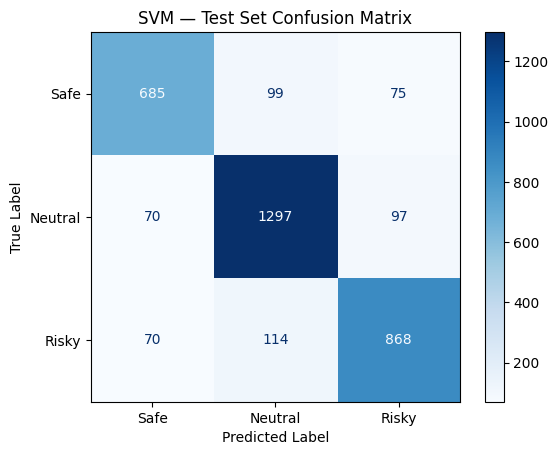

In [15]:
cm = confusion_matrix(
    y_val,
    y_val_pred,
    labels=["Safe", "Neutral", "Risky"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Safe", "Neutral", "Risky"]
)

disp.plot(cmap="Blues", values_format="d")

plt.title("SVM — Test Set Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Model: Linear SVM
TF-IDF features: 50,192
C: 1.0

Validation:
Accuracy:        0.8444
Macro Precision: 0.8413
Macro Recall:    0.8362
Macro F1:        0.8385
Weighted F1:     0.8441
Risky Recall:    0.8251

In [16]:


C_values = [0.01, 0.1, 1, 10, 100]

tuning_results = []

for C in C_values:

    model = LinearSVC(
        C=C,
        random_state=42,
        max_iter=10000
    )

    model.fit(X_train_tfidf, y_train)

    y_val_pred = model.predict(X_val_tfidf)

    tuning_results.append({
        "C": C,
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Macro Precision": precision_score(
            y_val, y_val_pred, average="macro"
        ),
        "Macro Recall": recall_score(
            y_val, y_val_pred, average="macro"
        ),
        "Macro F1": f1_score(
            y_val, y_val_pred, average="macro"
        ),
        "Weighted F1": f1_score(
            y_val, y_val_pred, average="weighted"
        ),
        "Risky Recall": recall_score(
            y_val,
            y_val_pred,
            labels=["Risky"],
            average="macro"
        )
    })

tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df

,C,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Risky Recall
0,0.01,0.739259,0.771037,0.703321,0.718270,0.731005,0.684411
1,0.10,0.834667,0.832223,0.824204,0.827663,0.834063,0.822243
2,1.00,0.844444,0.841286,0.836154,0.838531,0.844073,0.825095
3,10.00,0.826963,0.822463,0.819263,0.820781,0.826702,0.807034
4,100.00,0.824593,0.818915,0.816229,0.817511,0.824329,0.806084


In [17]:
import os

# Create results folder if it doesn't exist
os.makedirs("results", exist_ok=True)

# Save Linear SVM tuning results
tuning_results_df.to_csv(
    "results/svm_linear_tuning.csv",
    index=False
)

print("Saved: results/svm_linear_tuning.csv")

Saved: results/svm_linear_tuning.csv


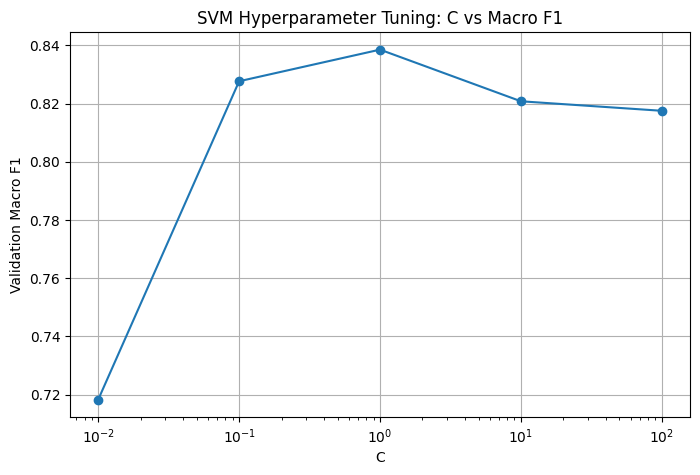

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    tuning_results_df["C"],
    tuning_results_df["Macro F1"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("C")
plt.ylabel("Validation Macro F1")
plt.title("SVM Hyperparameter Tuning: C vs Macro F1")

plt.grid(True)
plt.show()

In [19]:
best_row = tuning_results_df.loc[
    tuning_results_df["Macro F1"].idxmax()
]

best_C = best_row["C"]

print("Best C:", best_C)
print("Best Validation Macro F1:", best_row["Macro F1"])

Best C: 1.0
Best Validation Macro F1: 0.8385310221914478


SVM Training, Validation, and Testing Process

For the SVM model, the dataset was divided into three parts: 70% training data, 15% validation data, and 15% test data.

The 70% training data was used to train the SVM model. The 15% validation data was used during the model selection and hyperparameter tuning stage. We tested different values of the SVM parameter C — 0.01, 0.1, 1, 10, and 100 — and compared their performance using metrics such as accuracy, macro F1-score, weighted F1-score, and Risky recall.

The validation results showed that C = 1 performed the best, achieving a validation accuracy of 84.44% and a macro F1-score of 83.85%. Therefore, C = 1 was selected as the final SVM hyperparameter.

The 15% test data was not used during training or hyperparameter tuning. It was kept completely separate to provide an unbiased evaluation of the final model.

After selecting C = 1, the training and validation datasets were combined, giving us 85% of the total dataset. The final SVM model was then retrained using this combined 85% dataset.

In [20]:
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

In [21]:
final_tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_final_tfidf = final_tfidf.fit_transform(X_train_final)
X_test_final_tfidf = final_tfidf.transform(X_test)

In [22]:
final_tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_final_tfidf = final_tfidf.fit_transform(X_train_final)
X_test_final_tfidf = final_tfidf.transform(X_test)

In [23]:
# ==========================================
# FINAL SVM TRAINING
# ==========================================

final_svm = LinearSVC(
    C=1.0,
    random_state=42
)

start_train = time.perf_counter()

final_svm.fit(
    X_train_final_tfidf,
    y_train_final
)

training_time = time.perf_counter() - start_train

print(f"Training time: {training_time:.4f} seconds")

Training time: 0.5773 seconds


In [24]:
# ==========================================
# FINAL SVM PREDICTION
# ==========================================

start_inference = time.perf_counter()

y_test_pred = final_svm.predict(
    X_test_final_tfidf
)

inference_time = time.perf_counter() - start_inference

print(f"Inference time: {inference_time:.4f} seconds")

Inference time: 0.0025 seconds


In [25]:
print(
    classification_report(
        y_test,
        y_test_pred,
        labels=["Safe", "Neutral", "Risky"]
    )
)

              precision    recall  f1-score   support

        Safe       0.84      0.80      0.82       858
     Neutral       0.87      0.88      0.88      1464
       Risky       0.81      0.83      0.82      1053

    accuracy                           0.84      3375
   macro avg       0.84      0.84      0.84      3375
weighted avg       0.84      0.84      0.84      3375



In [26]:
# ==========================================
# FINAL SVM METRICS
# ==========================================

labels = ["Safe", "Neutral", "Risky"]

# Overall
accuracy = accuracy_score(y_test, y_test_pred)

macro_precision = precision_score(
    y_test,
    y_test_pred,
    average="macro"
)

macro_recall = recall_score(
    y_test,
    y_test_pred,
    average="macro"
)

macro_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro"
)

weighted_f1 = f1_score(
    y_test,
    y_test_pred,
    average="weighted"
)

# Per-class
precision_per_class = precision_score(
    y_test,
    y_test_pred,
    labels=labels,
    average=None
)

recall_per_class = recall_score(
    y_test,
    y_test_pred,
    labels=labels,
    average=None
)

f1_per_class = f1_score(
    y_test,
    y_test_pred,
    labels=labels,
    average=None
)

# Risky-specific
risky_recall = recall_score(
    y_test,
    y_test_pred,
    labels=["Risky"],
    average="macro"
)

risky_f1 = f1_score(
    y_test,
    y_test_pred,
    labels=["Risky"],
    average="macro"
)

print("Accuracy:", accuracy)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)
print("Risky Recall:", risky_recall)
print("Risky F1:", risky_f1)

Accuracy: 0.8447407407407408
Macro Precision: 0.8410098483429387
Macro Recall: 0.8372685214670642
Macro F1: 0.8389399242787036
Weighted F1: 0.8446158196362058
Risky Recall: 0.8281101614434948
Risky F1: 0.8187793427230047


In [27]:
# ==========================================
# SAVE OVERALL METRICS
# ==========================================

overall_results = pd.DataFrame([{
    "Model": "Linear SVM",
    "C": 1.0,
    "Accuracy": accuracy,
    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Macro F1": macro_f1,
    "Weighted F1": weighted_f1,
    "Risky Recall": risky_recall,
    "Risky F1": risky_f1,
    "Training Time (seconds)": training_time,
    "Inference Time (seconds)": inference_time
}])

overall_results.to_csv(
    "results/svm_final_results.csv",
    index=False
)

overall_results

,Model,C,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Risky Recall,Risky F1,Training Time (seconds),Inference Time (seconds)
0,Linear SVM,1.0,0.844741,0.84101,0.837269,0.83894,0.844616,0.82811,0.818779,0.577266,0.002473


In [28]:
# ==========================================
# SAVE PER-CLASS METRICS
# ==========================================

class_results = pd.DataFrame({
    "Class": labels,
    "Precision": precision_per_class,
    "Recall": recall_per_class,
    "F1 Score": f1_per_class
})

class_results.to_csv(
    "results/svm_linear_per_class_results.csv",
    index=False
)

class_results

,Class,Precision,Recall,F1 Score
0,Safe,0.841076,0.801865,0.821002
1,Neutral,0.872297,0.881831,0.877038
2,Risky,0.809656,0.828110,0.818779


<Figure size 700x600 with 0 Axes>

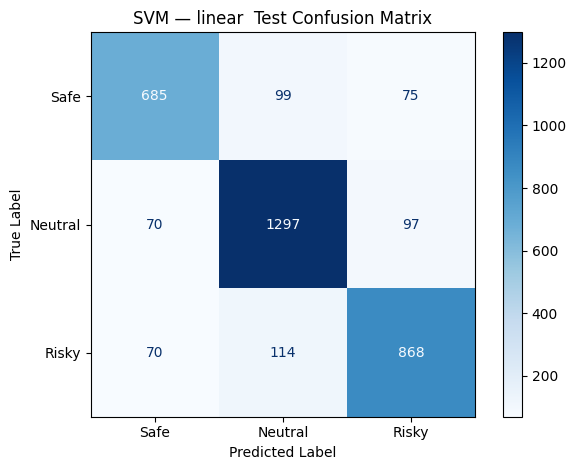

In [30]:
plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Safe", "Neutral", "Risky"]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("SVM — linear  Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.savefig(
    "results/svm_linear_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

till now we have done for linear SVC , lets check for RBF baseline and compare the results to get the better model 

In [31]:
import time
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [32]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

In [33]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [34]:
# ==========================================
# RBF SVM BASELINE
# ==========================================

rbf_svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

start_time = time.perf_counter()

rbf_svm.fit(
    X_train_tfidf,
    y_train
)

rbf_training_time = time.perf_counter() - start_time

print(f"RBF SVM training time: {rbf_training_time:.2f} seconds")

RBF SVM training time: 156.58 seconds


In [35]:
# ==========================================
# RBF VALIDATION PREDICTION
# ==========================================

start_time = time.perf_counter()

y_val_pred_rbf = rbf_svm.predict(X_val_tfidf)

rbf_validation_prediction_time = time.perf_counter() - start_time

print(
    f"Validation prediction time: "
    f"{rbf_validation_prediction_time:.2f} seconds"
)

Validation prediction time: 17.75 seconds


In [36]:
print(classification_report(
    y_val,
    y_val_pred_rbf,
    labels=["Safe", "Neutral", "Risky"]
))

              precision    recall  f1-score   support

        Safe       0.85      0.77      0.81       859
     Neutral       0.86      0.90      0.88      1464
       Risky       0.83      0.84      0.83      1052

    accuracy                           0.85      3375
   macro avg       0.84      0.84      0.84      3375
weighted avg       0.85      0.85      0.85      3375



In [37]:
rbf_val_accuracy = accuracy_score(y_val, y_val_pred_rbf)

rbf_val_macro_precision = precision_score(
    y_val, y_val_pred_rbf, average="macro"
)

rbf_val_macro_recall = recall_score(
    y_val, y_val_pred_rbf, average="macro"
)

rbf_val_macro_f1 = f1_score(
    y_val, y_val_pred_rbf, average="macro"
)

rbf_val_weighted_f1 = f1_score(
    y_val, y_val_pred_rbf, average="weighted"
)

rbf_val_risky_recall = recall_score(
    y_val,
    y_val_pred_rbf,
    labels=["Risky"],
    average="macro"
)

rbf_val_risky_f1 = f1_score(
    y_val,
    y_val_pred_rbf,
    labels=["Risky"],
    average="macro"
)

print("RBF Validation Results")
print("----------------------")
print(f"Accuracy:       {rbf_val_accuracy:.4f}")
print(f"Macro Precision:{rbf_val_macro_precision:.4f}")
print(f"Macro Recall:   {rbf_val_macro_recall:.4f}")
print(f"Macro F1:       {rbf_val_macro_f1:.4f}")
print(f"Weighted F1:    {rbf_val_weighted_f1:.4f}")
print(f"Risky Recall:   {rbf_val_risky_recall:.4f}")
print(f"Risky F1:       {rbf_val_risky_f1:.4f}")

RBF Validation Results
----------------------
Accuracy:       0.8462
Macro Precision:0.8446
Macro Recall:   0.8353
Macro F1:       0.8393
Weighted F1:    0.8455
Risky Recall:   0.8375
Risky F1:       0.8343


In [38]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd
import time

C_values = [0.1, 1, 10]
gamma_values = [0.001, 0.01, 0.1]

rbf_tuning_results = []

for C in C_values:
    for gamma in gamma_values:

        print(f"Training RBF SVM: C={C}, gamma={gamma}")

        # Train
        start_time = time.perf_counter()

        rbf_model = SVC(
            kernel="rbf",
            C=C,
            gamma=gamma
        )

        rbf_model.fit(X_train_tfidf, y_train)

        training_time = time.perf_counter() - start_time

        # Validation prediction
        start_time = time.perf_counter()

        y_val_pred = rbf_model.predict(X_val_tfidf)

        prediction_time = time.perf_counter() - start_time

        # Metrics
        accuracy = accuracy_score(y_val, y_val_pred)

        macro_precision = precision_score(
            y_val, y_val_pred,
            average="macro",
            zero_division=0
        )

        macro_recall = recall_score(
            y_val, y_val_pred,
            average="macro",
            zero_division=0
        )

        macro_f1 = f1_score(
            y_val, y_val_pred,
            average="macro",
            zero_division=0
        )

        weighted_f1 = f1_score(
            y_val, y_val_pred,
            average="weighted",
            zero_division=0
        )

        risky_recall = recall_score(
            y_val, y_val_pred,
            labels=["Risky"],
            average=None,
            zero_division=0
        )[0]

        risky_f1 = f1_score(
            y_val, y_val_pred,
            labels=["Risky"],
            average=None,
            zero_division=0
        )[0]

        # Store results
        rbf_tuning_results.append({
            "C": C,
            "Gamma": gamma,
            "Accuracy": accuracy,
            "Macro Precision": macro_precision,
            "Macro Recall": macro_recall,
            "Macro F1": macro_f1,
            "Weighted F1": weighted_f1,
            "Risky Recall": risky_recall,
            "Risky F1": risky_f1,
            "Training Time (seconds)": training_time,
            "Validation Prediction Time (seconds)": prediction_time
        })

        print(
            f"Accuracy: {accuracy:.4f} | "
            f"Macro F1: {macro_f1:.4f} | "
            f"Risky Recall: {risky_recall:.4f} | "
            f"Time: {training_time:.2f}s"
        )

# Convert to DataFrame
rbf_tuning_df = pd.DataFrame(rbf_tuning_results)

# Sort by Macro F1
rbf_tuning_df = rbf_tuning_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

rbf_tuning_df


Training RBF SVM: C=0.1, gamma=0.001
Accuracy: 0.4338 | Macro F1: 0.2017 | Risky Recall: 0.0000 | Time: 124.57s
Training RBF SVM: C=0.1, gamma=0.01
Accuracy: 0.4338 | Macro F1: 0.2017 | Risky Recall: 0.0000 | Time: 135.64s
Training RBF SVM: C=0.1, gamma=0.1
Accuracy: 0.4747 | Macro F1: 0.2966 | Risky Recall: 0.0894 | Time: 108.39s
Training RBF SVM: C=1, gamma=0.001
Accuracy: 0.4338 | Macro F1: 0.2017 | Risky Recall: 0.0000 | Time: 111.81s
Training RBF SVM: C=1, gamma=0.01
Accuracy: 0.5253 | Macro F1: 0.3970 | Risky Recall: 0.2177 | Time: 96.63s
Training RBF SVM: C=1, gamma=0.1
Accuracy: 0.8133 | Macro F1: 0.8026 | Risky Recall: 0.8184 | Time: 72.14s
Training RBF SVM: C=10, gamma=0.001
Accuracy: 0.5298 | Macro F1: 0.4057 | Risky Recall: 0.2281 | Time: 100.22s
Training RBF SVM: C=10, gamma=0.01
Accuracy: 0.8184 | Macro F1: 0.8087 | Risky Recall: 0.8194 | Time: 70.40s
Training RBF SVM: C=10, gamma=0.1
Accuracy: 0.8465 | Macro F1: 0.8397 | Risky Recall: 0.8232 | Time: 71.57s


,C,Gamma,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Risky Recall,Risky F1,Training Time (seconds),Validation Prediction Time (seconds)
0,10.0,0.100,0.846519,0.843029,0.836928,0.839711,0.846009,0.823194,0.830695,71.565381,12.401624
1,10.0,0.010,0.818370,0.821829,0.801631,0.808666,0.816556,0.819392,0.807873,70.402233,13.387052
2,1.0,0.100,0.813333,0.818824,0.794625,0.802600,0.810966,0.818441,0.808451,72.142020,13.620489
3,10.0,0.001,0.529778,0.775546,0.444380,0.405746,0.446921,0.228137,0.361718,100.221410,18.217162
4,1.0,0.010,0.525333,0.775642,0.439022,0.397021,0.439161,0.217681,0.348819,96.631270,17.472910
5,0.1,0.100,0.474667,0.788548,0.380673,0.296561,0.347456,0.089354,0.162771,108.394277,18.900419
6,0.1,0.001,0.433778,0.144593,0.333333,0.201695,0.262472,0.000000,0.000000,124.569460,20.860931
7,1.0,0.001,0.433778,0.144593,0.333333,0.201695,0.262472,0.000000,0.000000,111.812057,17.541893
8,0.1,0.010,0.433778,0.144593,0.333333,0.201695,0.262472,0.000000,0.000000,135.635161,19.238048


In [39]:
import os

os.makedirs("results", exist_ok=True)

rbf_tuning_df.to_csv(
    "results/svm_rbf_tuning.csv",
    index=False
)

print("Saved: results/svm_rbf_tuning.csv")

Saved: results/svm_rbf_tuning.csv


In [40]:
print(classification_report(
    y_val,
    y_val_pred_rbf,
    labels=["Safe", "Neutral", "Risky"]
))

              precision    recall  f1-score   support

        Safe       0.85      0.77      0.81       859
     Neutral       0.86      0.90      0.88      1464
       Risky       0.83      0.84      0.83      1052

    accuracy                           0.85      3375
   macro avg       0.84      0.84      0.84      3375
weighted avg       0.85      0.85      0.85      3375



In [41]:
rbf_val_accuracy = accuracy_score(y_val, y_val_pred_rbf)

rbf_val_macro_precision = precision_score(
    y_val, y_val_pred_rbf, average="macro"
)

rbf_val_macro_recall = recall_score(
    y_val, y_val_pred_rbf, average="macro"
)

rbf_val_macro_f1 = f1_score(
    y_val, y_val_pred_rbf, average="macro"
)

rbf_val_weighted_f1 = f1_score(
    y_val, y_val_pred_rbf, average="weighted"
)

rbf_val_risky_recall = recall_score(
    y_val,
    y_val_pred_rbf,
    labels=["Risky"],
    average="macro"
)

rbf_val_risky_f1 = f1_score(
    y_val,
    y_val_pred_rbf,
    labels=["Risky"],
    average="macro"
)

print("RBF Validation Results")
print("----------------------")
print(f"Accuracy:       {rbf_val_accuracy:.4f}")
print(f"Macro Precision:{rbf_val_macro_precision:.4f}")
print(f"Macro Recall:   {rbf_val_macro_recall:.4f}")
print(f"Macro F1:       {rbf_val_macro_f1:.4f}")
print(f"Weighted F1:    {rbf_val_weighted_f1:.4f}")
print(f"Risky Recall:   {rbf_val_risky_recall:.4f}")
print(f"Risky F1:       {rbf_val_risky_f1:.4f}")

RBF Validation Results
----------------------
Accuracy:       0.8462
Macro Precision:0.8446
Macro Recall:   0.8353
Macro F1:       0.8393
Weighted F1:    0.8455
Risky Recall:   0.8375
Risky F1:       0.8343


In [42]:
# ==========================================
# FINAL RBF SVM
# ==========================================

from sklearn.svm import SVC

final_rbf_model = SVC(
    kernel="rbf",
    C=10,
    gamma=0.1
)

start_time = time.perf_counter()

final_rbf_model.fit(
    X_train_final_tfidf,
    y_train_final
)

final_rbf_training_time = time.perf_counter() - start_time

print(
    f"Final RBF training time: "
    f"{final_rbf_training_time:.2f} seconds"
)

Final RBF training time: 177.36 seconds


In [43]:
# ==========================================
# FINAL RBF TEST PREDICTION
# ==========================================

start_time = time.perf_counter()

y_test_pred_rbf = final_rbf_model.predict(
    X_test_final_tfidf
)

final_rbf_inference_time = time.perf_counter() - start_time

print(
    f"Final RBF inference time: "
    f"{final_rbf_inference_time:.4f} seconds"
)

Final RBF inference time: 15.8818 seconds


In [44]:
# ==========================================
# FINAL RBF TEST METRICS
# ==========================================

accuracy = accuracy_score(
    y_test,
    y_test_pred_rbf
)

macro_precision = precision_score(
    y_test,
    y_test_pred_rbf,
    average="macro"
)

macro_recall = recall_score(
    y_test,
    y_test_pred_rbf,
    average="macro"
)

macro_f1 = f1_score(
    y_test,
    y_test_pred_rbf,
    average="macro"
)

weighted_f1 = f1_score(
    y_test,
    y_test_pred_rbf,
    average="weighted"
)

risky_recall = recall_score(
    y_test,
    y_test_pred_rbf,
    labels=["Risky"],
    average="macro"
)

risky_f1 = f1_score(
    y_test,
    y_test_pred_rbf,
    labels=["Risky"],
    average="macro"
)

print("Final RBF Test Results")
print("----------------------")
print(f"Accuracy:       {accuracy:.4f}")
print(f"Macro Precision:{macro_precision:.4f}")
print(f"Macro Recall:   {macro_recall:.4f}")
print(f"Macro F1:       {macro_f1:.4f}")
print(f"Weighted F1:    {weighted_f1:.4f}")
print(f"Risky Recall:   {risky_recall:.4f}")
print(f"Risky F1:       {risky_f1:.4f}")

Final RBF Test Results
----------------------
Accuracy:       0.8498
Macro Precision:0.8457
Macro Recall:   0.8420
Macro F1:       0.8437
Weighted F1:    0.8496
Risky Recall:   0.8310
Risky F1:       0.8259


In [45]:
labels = ["Safe", "Neutral", "Risky"]

rbf_cm = confusion_matrix(
    y_test,
    y_test_pred_rbf,
    labels=labels
)

rbf_cm_df = pd.DataFrame(
    rbf_cm,
    index=["True Safe", "True Neutral", "True Risky"],
    columns=[
        "Predicted Safe",
        "Predicted Neutral",
        "Predicted Risky"
    ]
)

rbf_cm_df

,Predicted Safe,Predicted Neutral,Predicted Risky
True Safe,692,83,83
True Neutral,55,1301,108
True Risky,76,102,875


In [46]:
rbf_cm_df.to_csv(
    "results/svm_rbf_confusion_matrix.csv"
)

print("Saved: results/svm_rbf_confusion_matrix.csv")

Saved: results/svm_rbf_confusion_matrix.csv


In [47]:
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

labels = ["Safe", "Neutral", "Risky"]

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_test_pred_rbf,
    labels=labels,
    zero_division=0
)

rbf_per_class_df = pd.DataFrame({
    "Class": labels,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
})

print(rbf_per_class_df)

# Save to CSV
rbf_per_class_df.to_csv(
    "results/rbf_svm_per_class_metrics.csv",
    index=False
)

     Class  Precision    Recall  F1 Score
0     Safe   0.840826  0.806527  0.823319
1  Neutral   0.875505  0.888661  0.882034
2    Risky   0.820826  0.830959  0.825861


In [48]:
rbf_final_result = pd.DataFrame([{
    "Model": "RBF SVM",
    "C": 10.0,
    "Accuracy": accuracy,
    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Macro F1": macro_f1,
    "Weighted F1": weighted_f1,
    "Risky Recall": risky_recall,
    "Risky F1": risky_f1,
    "Training Time (seconds)": final_rbf_training_time,
    "Inference Time (seconds)": final_rbf_inference_time
}])

final_results_path = "results/svm_final_results.csv"

# Load existing results
final_results_df = pd.read_csv(final_results_path)

# Remove the old RBF validation row
final_results_df = final_results_df[
    final_results_df["Model"] != "RBF SVM"
]

# Add the NEW final RBF test result
final_results_df = pd.concat(
    [final_results_df, rbf_final_result],
    ignore_index=True
)

# Save correctly
final_results_df.to_csv(
    final_results_path,
    index=False
)

print("Updated:", final_results_path)
print(final_results_df)

Updated: results/svm_final_results.csv
        Model     C  Accuracy  Macro Precision  Macro Recall  Macro F1  \
0  Linear SVM   1.0  0.844741         0.841010      0.837269  0.838940   
1     RBF SVM  10.0  0.849778         0.845719      0.842049  0.843738   

   Weighted F1  Risky Recall  Risky F1  Training Time (seconds)  \
0     0.844616      0.828110  0.818779                 0.577266   
1     0.849582      0.830959  0.825861               177.364169   

   Inference Time (seconds)  
0                  0.002473  
1                 15.881846  


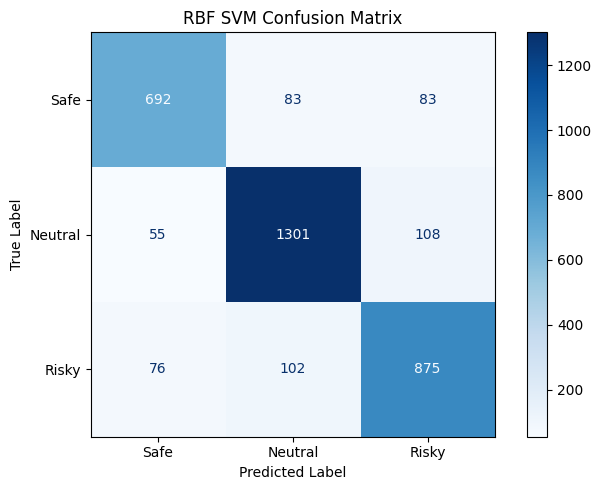

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

labels = ["Safe", "Neutral", "Risky"]

rbf_cm = confusion_matrix(
    y_test,
    y_test_pred_rbf,
    labels=labels
)

# Create confusion matrix display
disp = ConfusionMatrixDisplay(
    confusion_matrix=rbf_cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(7, 5))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

plt.title("RBF SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.savefig(
    "results/rbf_svm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()